In [10]:
import os
import json
import glob
import math
import pandas as pd
from shapely.geometry import shape, Point
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', 500)
pd.set_option('future.no_silent_downcasting', True)
import matplotlib.pyplot as plt

plt.close('all')  # close old figures
plt.rcParams['figure.figsize'] = (6, 4)  # default size
plt.rcParams['figure.dpi'] = 120        # decent resolution for VSCode inline

In [31]:
import os, glob
import openslide
import pandas as pd

WSI_DIR = "/Volumes/Expansion/wsi-annotated"
exts = ("*.mrxs", "*.svs", "*.ndpi", "*.tif", "*.tiff")

paths = []
for e in exts:
    paths += glob.glob(os.path.join(WSI_DIR, e))

rows = []
for p in sorted(paths):
    try:
        s = openslide.OpenSlide(p)
        W0, H0 = s.level_dimensions[0]
        bx = int(s.properties.get("openslide.bounds-x", 0))
        by = int(s.properties.get("openslide.bounds-y", 0))
        bw = s.properties.get("openslide.bounds-width", None)
        bh = s.properties.get("openslide.bounds-height", None)
        bw = int(bw) if bw is not None else None
        bh = int(bh) if bh is not None else None

        needs_shift = (bx != 0) or (by != 0)
        bounds_smaller = (bw is not None and bh is not None and (bw < W0 or bh < H0))

        rows.append({
            "file": os.path.basename(p),
            "ext": os.path.splitext(p)[1].lower(),
            "level0_W": W0, "level0_H": H0,
            "bounds_x": bx, "bounds_y": by,
            "bounds_W": bw, "bounds_H": bh,
            "needs_shift": needs_shift,
            "bounds_smaller_than_canvas": bounds_smaller,
        })
    except Exception as e:
        rows.append({"file": os.path.basename(p), "ext": os.path.splitext(p)[1].lower(), "error": str(e)})

df = pd.DataFrame(rows)
print(df[["ext","needs_shift","bounds_smaller_than_canvas"]].value_counts(dropna=False))
df[df["needs_shift"] | df["bounds_smaller_than_canvas"]].sort_values(["ext","file"]).head(50)

ext    needs_shift  bounds_smaller_than_canvas
.svs   False        False                         55
.ndpi  False        False                         11
.mrxs  True         True                           4
.svs   NaN          NaN                            1
Name: count, dtype: int64


,file,ext,level0_W,level0_H,bounds_x,bounds_y,bounds_W,bounds_H,needs_shift,bounds_smaller_than_canvas,error
63,DigitalSlide_A1M_1S_1.mrxs,.mrxs,272128.0,294144.0,44800.0,80384.0,44800.0,37888.0,True,True,NaN
64,DigitalSlide_A1M_1S_1_20230920092719241.mrxs,.mrxs,272128.0,294144.0,14080.0,43264.0,92416.0,166656.0,True,True,NaN
65,DigitalSlide_A1M_2S_1.mrxs,.mrxs,272128.0,294144.0,195072.0,109312.0,33792.0,23296.0,True,True,NaN
66,DigitalSlide_A1M_2S_1_20230920093737845.mrxs,.mrxs,272128.0,294144.0,216832.0,104192.0,25344.0,35840.0,True,True,NaN


In [33]:
import os, glob, json
import pandas as pd
import numpy as np
from shapely.geometry import shape, Point
import openslide

# ---------------- SETTINGS ----------------
GEOJSON_DIR = "/Users/sandeepsharma/Downloads/Tumor patch extraction/annotations_geojson"
WSI_DIR     = "/Volumes/Expansion/wsi-annotated"
OUT_CSV     = "/Users/sandeepsharma/Downloads/Tumor patch extraction/train_coords.csv"

GRID_STEP_UM   = 56
MIN_PER_CLASS  = 50
MAX_PER_CLASS  = 5000

TUMOR_NAMES    = {"Tumor", "TUMOR_CORE", "Positive"}
NONTUMOR_NAMES = {"NON_TUMOR", "Negative", "Non-tumor", "Non_Tumor", "Normal"}
IGNORE_NAMES   = {"Ignore*", "IGNORE", "Ignore"}
# -----------------------------------------

def load_features(path):
    data = json.load(open(path, "r"))
    if isinstance(data, dict) and data.get("type") == "FeatureCollection":
        return data.get("features", [])
    if isinstance(data, list):
        return data
    raise ValueError(f"Unrecognized GeoJSON structure: {path}")

def get_class_name(feat):
    props = feat.get("properties", {})
    cls = props.get("classification", {})
    if isinstance(cls, dict) and "name" in cls:
        return cls["name"]
    return props.get("name", None)

def find_wsi(slide_id):
    exts = [".mrxs", ".svs", ".ndpi", ".tif", ".tiff"]
    for ext in exts:
        p = os.path.join(WSI_DIR, slide_id + ext)
        if os.path.exists(p):
            return p
    hits = glob.glob(os.path.join(WSI_DIR, slide_id + ".*"))
    if hits:
        return hits[0]
    return None

def get_meta(path):
    s = openslide.OpenSlide(path)
    mpp0 = (float(s.properties["openslide.mpp-x"]) + float(s.properties["openslide.mpp-y"])) / 2.0
    bx = int(s.properties.get("openslide.bounds-x", 0))
    by = int(s.properties.get("openslide.bounds-y", 0))
    bw = s.properties.get("openslide.bounds-width", None)
    bh = s.properties.get("openslide.bounds-height", None)
    bw = int(bw) if bw is not None else None
    bh = int(bh) if bh is not None else None
    return mpp0, bx, by, bw, bh

def sample_points_in_polygons(polys, step_px):
    if not polys:
        return []
    minx = min(p.bounds[0] for p in polys)
    miny = min(p.bounds[1] for p in polys)
    maxx = max(p.bounds[2] for p in polys)
    maxy = max(p.bounds[3] for p in polys)

    xs = np.arange(minx, maxx + 1e-6, step_px)
    ys = np.arange(miny, maxy + 1e-6, step_px)

    pts = []
    for x in xs:
        for y in ys:
            pt = Point(float(x), float(y))
            if any(p.contains(pt) for p in polys):
                pts.append((int(round(x)), int(round(y))))
    return pts

def filter_ignore(pts, ignore_polys):
    if not ignore_polys:
        return pts
    kept = []
    for x, y in pts:
        pt = Point(x, y)
        if any(p.contains(pt) for p in ignore_polys):
            continue
        kept.append((x, y))
    return kept

rows = []
gj_files = sorted(glob.glob(os.path.join(GEOJSON_DIR, "*.geojson")))

for gj_path in gj_files:
    slide_id = os.path.splitext(os.path.basename(gj_path))[0]
    wsi_path = find_wsi(slide_id)
    if wsi_path is None:
        print(f"[skip] no WSI for {slide_id}")
        continue

    # open slide meta (skip corrupt)
    try:
        mpp0, bx, by, bw, bh = get_meta(wsi_path)
    except Exception as e:
        print(f"[skip] cannot open {wsi_path}: {e}")
        continue

    feats = load_features(gj_path)
    tumor_polys, nontumor_polys, ignore_polys = [], [], []

    for f in feats:
        if f.get("geometry") is None:
            continue
        cname = get_class_name(f)
        if cname is None:
            continue
        geom = shape(f["geometry"])
        if geom.is_empty:
            continue

        if cname in IGNORE_NAMES:
            ignore_polys.append(geom)
        elif cname in TUMOR_NAMES:
            tumor_polys.append(geom)
        elif cname in NONTUMOR_NAMES:
            nontumor_polys.append(geom)

    # ✅ step based on native mpp0 (not TARGET_MPP)
    step_px = GRID_STEP_UM / mpp0

    tumor_pts = filter_ignore(sample_points_in_polygons(tumor_polys, step_px), ignore_polys)
    nontumor_pts = filter_ignore(sample_points_in_polygons(nontumor_polys, step_px), ignore_polys)

    # MRXS bounds safety: QuPath coords must lie within [0,bounds_w/h)
    if (bx != 0 or by != 0) and (bw is not None and bh is not None):
        tumor_pts = [(x,y) for (x,y) in tumor_pts if 0 <= x < bw and 0 <= y < bh]
        nontumor_pts = [(x,y) for (x,y) in nontumor_pts if 0 <= x < bw and 0 <= y < bh]

    tumor_pts = tumor_pts[:MAX_PER_CLASS]
    nontumor_pts = nontumor_pts[:MAX_PER_CLASS]

    if len(tumor_pts) < MIN_PER_CLASS and len(nontumor_pts) < MIN_PER_CLASS:
        print(f"[skip] too few points: {slide_id} tumor={len(tumor_pts)} non={len(nontumor_pts)}")
        continue

    for x, y in tumor_pts:
        rows.append((slide_id, wsi_path, x, y, 1, mpp0, bx, by, bw, bh))
    for x, y in nontumor_pts:
        rows.append((slide_id, wsi_path, x, y, 0, mpp0, bx, by, bw, bh))

df = pd.DataFrame(rows, columns=[
    "slide_id","wsi_path","x_qp","y_qp","label","mpp0","bounds_x","bounds_y","bounds_w","bounds_h"
])
df.to_csv(OUT_CSV, index=False)

print(f"Saved {len(df):,} samples -> {OUT_CSV}")
print(df["label"].value_counts())
print("Slides:", df["slide_id"].nunique())

Saved 36,316 samples -> /Users/sandeepsharma/Downloads/Tumor patch extraction/train_coords.csv
label
1    29958
0     6358
Name: count, dtype: int64
Slides: 68


In [35]:
import os
import glob
import math
import pandas as pd
import numpy as np
import openslide
from PIL import Image

# -------------------- SETTINGS --------------------
CSV_PATH = "/Users/sandeepsharma/Downloads/Tumor patch extraction/train_coords.csv"
SLIDE_DIR = "/Volumes/Expansion/wsi-annotated"   # used only if wsi_path missing
OUT_DIR  = "/Users/sandeepsharma/Downloads/Tumor patch extraction/sample_patches"

TARGET_MPP = 0.50        # ~20x physical scale
PATCH_OUT = 224          # model input size
N_PER_CLASS = 15         # number of patches per class to sample

EXTS = (".svs", ".ndpi", ".mrxs", ".tif", ".tiff")
# --------------------------------------------------


def find_slide_path(slide_id: str) -> str:
    """Fallback finder if CSV doesn't have wsi_path."""
    if slide_id.lower().endswith(EXTS):
        candidate = os.path.join(SLIDE_DIR, slide_id)
        if os.path.exists(candidate):
            return candidate

    for ext in EXTS:
        pat = os.path.join(SLIDE_DIR, "**", f"{slide_id}{ext}")
        hits = glob.glob(pat, recursive=True)
        if hits:
            return hits[0]

    hits = []
    for ext in EXTS:
        hits.extend(glob.glob(os.path.join(SLIDE_DIR, "**", f"*{slide_id}*{ext}"), recursive=True))
    if hits:
        return hits[0]

    raise FileNotFoundError(f"Could not find slide for slide_id='{slide_id}' under {SLIDE_DIR}")


def get_mpp0(slide: openslide.OpenSlide) -> float:
    """Return average mpp at level 0."""
    props = slide.properties
    mx = props.get("openslide.mpp-x", None)
    my = props.get("openslide.mpp-y", None)
    if mx is not None and my is not None:
        mx = float(mx); my = float(my)
        if mx > 0 and my > 0:
            return (mx + my) / 2.0

    # Aperio sometimes stores in aperio.MPP
    if "aperio.MPP" in props:
        v = float(props["aperio.MPP"])
        if v > 0:
            return v

    # Fallback from objective power (rough)
    obj = props.get("openslide.objective-power", props.get("aperio.AppMag", None))
    if obj is not None:
        obj = float(obj)
        if obj >= 40:
            return 0.25
        if obj >= 20:
            return 0.50

    raise ValueError("MPP not found in slide metadata")


def read_patch_target_mpp(slide: openslide.OpenSlide, x0: int, y0: int,
                          patch_out: int = PATCH_OUT, target_mpp: float = TARGET_MPP) -> Image.Image:
    """
    Read a patch centered at (x0,y0) in *level-0 canvas coords*.
    Keeps physical FOV consistent by reading a larger/smaller region at level0 then resizing to patch_out.
    """
    mpp0 = get_mpp0(slide)

    # size at level 0 that corresponds to patch_out at target_mpp
    size0 = int(round(patch_out * target_mpp / mpp0))
    size0 = max(size0, 1)

    W, H = slide.level_dimensions[0]

    # treat input as center, convert to top-left
    x_tl = int(round(x0 - size0 / 2))
    y_tl = int(round(y0 - size0 / 2))

    # clamp top-left so region fits inside image
    x_tl = max(0, min(x_tl, max(0, W - size0)))
    y_tl = max(0, min(y_tl, max(0, H - size0)))

    region = slide.read_region((x_tl, y_tl), 0, (size0, size0)).convert("RGB")
    if size0 != patch_out:
        region = region.resize((patch_out, patch_out), resample=Image.BILINEAR)
    return region


def make_montage(images, ncols=5, pad=4) -> Image.Image:
    if not images:
        raise ValueError("No images for montage")
    w, h = images[0].size
    n = len(images)
    nrows = math.ceil(n / ncols)
    canvas = Image.new("RGB", (ncols * w + (ncols - 1) * pad, nrows * h + (nrows - 1) * pad), (255, 255, 255))
    for idx, im in enumerate(images):
        r = idx // ncols
        c = idx % ncols
        x = c * (w + pad)
        y = r * (h + pad)
        canvas.paste(im, (x, y))
    return canvas


def is_black(im: Image.Image, thr=5.0, frac_thr=0.80):
    arr = np.asarray(im, dtype=np.uint8)
    mean = float(arr.mean())
    black_frac = float((arr.mean(axis=2) <= 5).mean())
    return (mean < thr) or (black_frac >= frac_thr), mean, black_frac


def main():
    os.makedirs(OUT_DIR, exist_ok=True)
    tumor_dir = os.path.join(OUT_DIR, "tumor")
    nontumor_dir = os.path.join(OUT_DIR, "non_tumor")
    os.makedirs(tumor_dir, exist_ok=True)
    os.makedirs(nontumor_dir, exist_ok=True)

    df = pd.read_csv(CSV_PATH)

    # Accept either (x_qp,y_qp) or legacy (x,y)
    if "x_qp" in df.columns and "y_qp" in df.columns:
        xcol, ycol = "x_qp", "y_qp"
    elif "x" in df.columns and "y" in df.columns:
        xcol, ycol = "x", "y"
    else:
        raise ValueError("CSV must contain either x_qp/y_qp or x/y")

    # bounds columns optional (0 for non-bounded slides)
    for c in ["bounds_x", "bounds_y"]:
        if c not in df.columns:
            df[c] = 0

    # use wsi_path if present
    has_wsi_path = "wsi_path" in df.columns

    # Sample per class
    df_t = df[df["label"] == 1].sample(n=min(N_PER_CLASS, int((df["label"] == 1).sum())), random_state=42)
    df_n = df[df["label"] == 0].sample(n=min(N_PER_CLASS, int((df["label"] == 0).sum())), random_state=42)

    def extract_set(subdf, out_subdir, prefix):
        ims = []
        for i, row in enumerate(subdf.itertuples(index=False), start=1):
            slide_id = getattr(row, "slide_id")
            x_qp = int(getattr(row, xcol))
            y_qp = int(getattr(row, ycol))
            bx = int(getattr(row, "bounds_x"))
            by = int(getattr(row, "bounds_y"))

            # ✅ bounds shift for MRXS (bx/by=0 for SVS/NDPI)
            x0 = x_qp + bx
            y0 = y_qp + by

            if has_wsi_path:
                slide_path = getattr(row, "wsi_path")
            else:
                slide_path = find_slide_path(slide_id)

            slide = openslide.OpenSlide(slide_path)
            im = read_patch_target_mpp(slide, x0, y0)
            slide.close()

            bad, mean, black_frac = is_black(im)
            if bad:
                print(f"[warn] black-ish patch: {prefix} {slide_id} x_qp={x_qp} y_qp={y_qp} "
                      f"-> x0={x0} y0={y0} mean={mean:.2f} black_frac={black_frac:.2f}")

            fname = f"{prefix}_{i:02d}__{os.path.basename(slide_path)}__xqp{x_qp}_yqp{y_qp}__x0{x0}_y0{y0}.png"
            im.save(os.path.join(out_subdir, fname))
            ims.append(im)
        return ims

    tumor_ims = extract_set(df_t, tumor_dir, "tumor")
    nontumor_ims = extract_set(df_n, nontumor_dir, "nontumor")

    make_montage(tumor_ims, ncols=5).save(os.path.join(OUT_DIR, "tumor_montage.png"))
    make_montage(nontumor_ims, ncols=5).save(os.path.join(OUT_DIR, "nontumor_montage.png"))

    print("DONE")
    print("Saved to:", OUT_DIR)
    print("Tumor montage:", os.path.join(OUT_DIR, "tumor_montage.png"))
    print("Non-tumor montage:", os.path.join(OUT_DIR, "nontumor_montage.png"))


if __name__ == "__main__":
    main()

DONE
Saved to: /Users/sandeepsharma/Downloads/Tumor patch extraction/sample_patches
Tumor montage: /Users/sandeepsharma/Downloads/Tumor patch extraction/sample_patches/tumor_montage.png
Non-tumor montage: /Users/sandeepsharma/Downloads/Tumor patch extraction/sample_patches/nontumor_montage.png


In [34]:
# import os
# import random
# from pathlib import Path

# import numpy as np
# import pandas as pd
# from PIL import Image, ImageFile, PngImagePlugin
# import openslide
# import matplotlib.pyplot as plt


# # -------------------------
# # CONFIG
# # -------------------------
# CSV_PATH = "/Users/sandeepsharma/Downloads/Tumor patch extraction/train_coords.csv"
# WSI_ROOT = "/Volumes/Expansion/wsi-annotated"  # <-- set this to the folder containing all WSIs (can be nested)
# ALLOWED_EXT = {".svs", ".ndpi", ".mrxs", ".tif", ".tiff"}  # add more if needed

# TARGET_MPP = 0.50      # 20x-equivalent physical scale
# OUT_SIZE = 224         # model input size
# N_PER_CLASS = 15
# SEED = 7

# # -------------------------
# # Helpers
# # -------------------------
# def build_slide_index(wsi_root: str):
#     """
#     Build an index: slide_stem -> file_path
#     slide_stem is filename without extension (e.g., '001' from '001.svs').
#     If duplicates exist, we keep the first and warn.
#     """
#     idx = {}
#     dup = {}
#     for p in Path(wsi_root).rglob("*"):
#         if p.is_file() and p.suffix.lower() in ALLOWED_EXT:
#             stem = p.stem
#             if stem in idx:
#                 dup.setdefault(stem, []).append(str(p))
#             else:
#                 idx[stem] = str(p)
#     if dup:
#         print(f"WARNING: Found duplicate slide stems for {len(dup)} IDs. Using first match.")
#         # print a few examples
#         for k, v in list(dup.items())[:5]:
#             print(f"  {k}:")
#             print(f"    kept: {idx[k]}")
#             for vv in v[:3]:
#                 print(f"    alt : {vv}")
#     return idx

# def get_slide_mpp(slide: openslide.OpenSlide):
#     """
#     Robust-ish MPP extraction across vendors.
#     Returns (mpp_x, mpp_y) or (None, None) if not available.
#     """
#     props = slide.properties
#     # Common OpenSlide keys
#     candidates = [
#         ("openslide.mpp-x", "openslide.mpp-y"),
#         ("aperio.MPP", "aperio.MPP"),  # sometimes single value
#         ("hamamatsu.XResolution", "hamamatsu.YResolution"),  # NDPI uses resolution (rarely)
#     ]

#     # 1) openslide.mpp-x/y
#     if "openslide.mpp-x" in props and "openslide.mpp-y" in props:
#         return float(props["openslide.mpp-x"]), float(props["openslide.mpp-y"])

#     # 2) aperio.MPP (single)
#     if "aperio.MPP" in props:
#         m = float(props["aperio.MPP"])
#         return m, m

#     # 3) QuPath often shows pixel width/height; OpenSlide might store in TIFF resolution keys
#     # If not present, return None and fallback later
#     return None, None

# def read_patch_mpp_normalized(slide_path: str, x: int, y: int, target_mpp=TARGET_MPP, out_size=OUT_SIZE):
#     """
#     Read a patch centered/anchored at (x, y) in LEVEL-0 pixel coordinates,
#     but normalize physical scale to target_mpp via level-0 read + resize.
#     """
#     slide = openslide.OpenSlide(slide_path)

#     mpp_x, mpp_y = get_slide_mpp(slide)
#     if mpp_x is None or mpp_y is None:
#         # fallback: if missing MPP, assume 0.25 (common 40x). Better than breaking.
#         mpp_x = mpp_y = 0.25

#     slide_mpp = float((mpp_x + mpp_y) / 2.0)
#     scale = target_mpp / slide_mpp  # >1 means read larger at level0 then downsample

#     read_px = int(round(out_size * scale))
#     read_px = max(1, read_px)

#     # bounds-safe clamp
#     W, H = slide.dimensions
#     x0 = int(np.clip(x, 0, max(0, W - 1)))
#     y0 = int(np.clip(y, 0, max(0, H - 1)))

#     # ensure region fits; shift if near edge
#     if x0 + read_px > W:
#         x0 = max(0, W - read_px)
#     if y0 + read_px > H:
#         y0 = max(0, H - read_px)

#     region = slide.read_region((x0, y0), 0, (read_px, read_px)).convert("RGB")
#     if read_px != out_size:
#         region = region.resize((out_size, out_size), Image.BILINEAR)

#     slide.close()
#     return region, slide_mpp, read_px, (x0, y0)

# def plot_grid(patches, titles, ncols=5, figsize=(14, 8)):
#     n = len(patches)
#     nrows = int(np.ceil(n / ncols))
#     plt.figure(figsize=figsize)
#     for i, (img, t) in enumerate(zip(patches, titles), 1):
#         ax = plt.subplot(nrows, ncols, i)
#         ax.imshow(img)
#         ax.set_title(t, fontsize=8)
#         ax.axis("off")
#     plt.tight_layout()
#     plt.show()

# # -------------------------
# # Main
# # -------------------------
# random.seed(SEED)
# np.random.seed(SEED)

# df = pd.read_csv(CSV_PATH)
# assert set(["slide_id", "x", "y", "label"]).issubset(df.columns), df.columns

# # Make slide_id string-safe (e.g., 001 not 1)
# df["slide_id"] = df["slide_id"].astype(str)

# slide_index = build_slide_index(WSI_ROOT)

# missing = sorted(set(df["slide_id"]) - set(slide_index.keys()))
# if missing:
#     print(f"ERROR: {len(missing)} slide_ids not found under WSI_ROOT. Examples: {missing[:10]}")
#     print("Fix: set WSI_ROOT correctly OR ensure filenames match slide_id (stem).")
#     raise SystemExit(1)

# # sample
# tumor = df[df["label"] == 1].sample(min(N_PER_CLASS, (df["label"] == 1).sum()), random_state=SEED)
# nont = df[df["label"] == 0].sample(min(N_PER_CLASS, (df["label"] == 0).sum()), random_state=SEED)

# sample_df = pd.concat([tumor, nont], axis=0).sample(frac=1, random_state=SEED).reset_index(drop=True)

# patches, titles = [], []
# for r in sample_df.itertuples(index=False):
#     sid, x, y, lab = r.slide_id, int(r.x), int(r.y), int(r.label)
#     spath = slide_index[sid]
#     img, mpp, read_px, (x0, y0) = read_patch_mpp_normalized(spath, x, y)
#     patches.append(img)
#     titles.append(f"id={sid} lab={lab}\nxy=({x},{y}) mpp={mpp:.3f}\nread0={read_px}px")

# plot_grid(patches, titles, ncols=5)

AssertionError: Index(['slide_id', 'wsi_path', 'x_qp', 'y_qp', 'label', 'mpp0', 'bounds_x',
       'bounds_y', 'bounds_w', 'bounds_h'],
      dtype='object')

In [1]:
from PIL import Image

in_path  = "src/ref_image/target_reference.png"
out_path = "src/ref_image/target_reference_clean.png"

im = Image.open(in_path).convert("RGB")
im.save(out_path, format="PNG", optimize=True)
print("Saved:", out_path)

Saved: src/ref_image/target_reference_clean.png


In [36]:
import os
import random
from pathlib import Path

import numpy as np
from PIL import Image, ImageFile, PngImagePlugin
import matplotlib.pyplot as plt

# Pillow safety for weird PNG metadata
ImageFile.LOAD_TRUNCATED_IMAGES = True
PngImagePlugin.MAX_TEXT_CHUNK = 10 * 1024 * 1024

RAW_DIR = "/Users/sandeepsharma/Downloads/Tumor patch extraction/src/results/patches_raw"        # cfg.in_dir
NORM_DIR = "/Users/sandeepsharma/Downloads/Tumor patch extraction/src/results/patches_norm"      # cfg.out_dir
OUT_DIR  = "/Users/sandeepsharma/Downloads/Tumor patch extraction/src/results/qc_out"
N_SAMPLES = 60                          # change as you like
SEED = 7
WHITE_THR = 240                         # for tissue ratio heuristic

def load_rgb(p: Path):
    img = Image.open(p).convert("RGB")
    return np.asarray(img, dtype=np.uint8)

def tissue_ratio(arr_rgb: np.ndarray, white_thr=240) -> float:
    # tissue = any channel below white_thr
    nonwhite = np.any(arr_rgb < white_thr, axis=2)
    return float(nonwhite.mean())

def mean_intensity(arr_rgb: np.ndarray) -> float:
    return float(arr_rgb.mean())

def gather_relpaths(root: str):
    rootp = Path(root)
    rels = []
    for lab in ["0", "1"]:
        for p in sorted((rootp / lab).glob("*.png")):
            rels.append(Path(lab) / p.name)
    return rels

def main():
    os.makedirs(OUT_DIR, exist_ok=True)

    raw_rels = set(gather_relpaths(RAW_DIR))
    norm_rels = set(gather_relpaths(NORM_DIR))
    common = sorted(list(raw_rels.intersection(norm_rels)))

    if not common:
        raise RuntimeError(
            "No matching files found between RAW_DIR and NORM_DIR.\n"
            "Expected identical structure: RAW_DIR/{0,1}/*.png and NORM_DIR/{0,1}/*.png"
        )

    random.seed(SEED)
    sample = common if len(common) <= N_SAMPLES else random.sample(common, N_SAMPLES)

    # --- Make grid (each row: raw | normalized) ---
    n = len(sample)
    fig_h = max(6, int(n * 1.8))
    fig, axes = plt.subplots(n, 2, figsize=(10, fig_h))

    # axes shape handling when n==1
    if n == 1:
        axes = np.array([axes])

    # Collect stats
    rows = ["relpath,mean_raw,mean_norm,tissue_raw,tissue_norm"]

    for i, rel in enumerate(sample):
        raw_path = Path(RAW_DIR) / rel
        norm_path = Path(NORM_DIR) / rel

        raw = load_rgb(raw_path)
        norm = load_rgb(norm_path)

        mr, mn = mean_intensity(raw), mean_intensity(norm)
        tr, tn = tissue_ratio(raw, WHITE_THR), tissue_ratio(norm, WHITE_THR)

        rows.append(f"{rel.as_posix()},{mr:.3f},{mn:.3f},{tr:.4f},{tn:.4f}")

        ax0, ax1 = axes[i, 0], axes[i, 1]
        ax0.imshow(raw)
        ax1.imshow(norm)

        ax0.set_title(f"RAW  | {rel.as_posix()}", fontsize=9)
        ax1.set_title(f"NORM | mean {mn:.1f} | tissue {tn:.2f}", fontsize=9)

        ax0.axis("off")
        ax1.axis("off")

    plt.tight_layout()
    out_img = Path(OUT_DIR) / "qc_raw_vs_norm.png"
    fig.savefig(out_img, dpi=200)
    plt.close(fig)

    out_csv = Path(OUT_DIR) / "qc_raw_vs_norm_report.csv"
    out_csv.write_text("\n".join(rows), encoding="utf-8")

    print(f"[QC] matched pairs: {len(common)}")
    print(f"[QC] sampled pairs: {len(sample)}")
    print(f"[QC] saved: {out_img}")
    print(f"[QC] saved: {out_csv}")

if __name__ == "__main__":
    main()

[QC] matched pairs: 36018
[QC] sampled pairs: 60
[QC] saved: /Users/sandeepsharma/Downloads/Tumor patch extraction/src/results/qc_out/qc_raw_vs_norm.png
[QC] saved: /Users/sandeepsharma/Downloads/Tumor patch extraction/src/results/qc_out/qc_raw_vs_norm_report.csv


In [12]:
import os
from pathlib import Path
import numpy as np
from PIL import Image
from tqdm import tqdm

# -------- CONFIG --------
ROOT = Path("/Users/sandeepsharma/Downloads/Tumor patch extraction/src/results/patches_raw")  # contains 0/ and 1/
BLACK_THR = 15          # pixel <= 15 considered black
MAX_BLACK_FRAC = 0.95   # if ≥95% black → delete
MIN_MEAN = 10.0         # safety: also delete very dark tiles
DRY_RUN = True         # set True to preview without deleting
# ------------------------


def black_fraction(rgb: np.ndarray, thr: int = 15) -> float:
    b = (rgb[..., 0] <= thr) & (rgb[..., 1] <= thr) & (rgb[..., 2] <= thr)
    return float(b.mean())


deleted = 0
kept = 0
errors = 0

paths = []
for lab in ["0", "1"]:
    paths.extend(sorted((ROOT / lab).glob("*.png")))

print(f"Scanning {len(paths)} normalized patches...")

for p in tqdm(paths):
    try:
        img = Image.open(p).convert("RGB")
        rgb = np.asarray(img, dtype=np.uint8)

        mean_intensity = float(rgb.mean())
        bf = black_fraction(rgb, BLACK_THR)

        is_black = (bf >= MAX_BLACK_FRAC) or (mean_intensity < MIN_MEAN)

        if is_black:
            if DRY_RUN:
                print(f"[DRY] would delete: {p.name} | mean={mean_intensity:.1f} black_frac={bf:.2f}")
            else:
                p.unlink()
                deleted += 1
        else:
            kept += 1

    except Exception as e:
        errors += 1
        if not DRY_RUN:
            try:
                p.unlink()   # corrupted file → delete
                deleted += 1
            except Exception:
                pass

print("\n---- SUMMARY ----")
print(f"Kept:     {kept}")
print(f"Deleted:  {deleted}")
print(f"Errors:   {errors}")

Scanning 27848 normalized patches...


 22%|██▏       | 6056/27848 [00:39<00:21, 990.74it/s]

[DRY] would delete: DigitalSlide_A1M_1S_1_20230920092719241__x2686__y12243__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1_20230920092719241__x2686__y12467__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1_20230920092719241__x2686__y12691__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1_20230920092719241__x2686__y12915__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1_20230920092719241__x2686__y13139__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1_20230920092719241__x2686__y13363__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1_20230920092719241__x2910__y10003__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1_20230920092719241__x2910__y10227__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: Digi

 94%|█████████▍| 26222/27848 [02:43<00:01, 1037.14it/s]

[DRY] would delete: DigitalSlide_A1M_1S_1__x10399__y17811__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1__x10399__y18035__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1__x10399__y18259__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1__x10399__y18483__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1__x10399__y18707__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1__x10399__y18931__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1__x10623__y17811__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1__x10623__y18035__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1__x10623__y18259__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_1S_1__x10623__y184

...

[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x10486__y23419__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x10486__y23643__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x10486__y23867__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x10710__y22747__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x10710__y22971__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x10710__y23195__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x10710__y23419__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x10710__y23643__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would dele

 96%|█████████▌| 26781/27848 [02:43<00:00, 1292.51it/s]

[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x5782__y24091__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x5782__y24315__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x6006__y22971__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x6006__y23195__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x6006__y23419__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x6006__y23643__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x6006__y23867__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: DigitalSlide_A1M_2S_1_20230920093737845__x6006__y24091__mpp0.243__r462.png | mean=0.0 black_frac=1.00
[DRY] would delete: Digi

100%|██████████| 27848/27848 [02:46<00:00, 167.07it/s] 


---- SUMMARY ----
Kept:     26695
Deleted:  0
Errors:   0


In [25]:
import openslide

mrxs_path = "/Volumes/Expansion/wsi-annotated/DigitalSlide_A1M_1S_1_20230920092719241.mrxs"
slide = openslide.OpenSlide(mrxs_path)

print("level0 dims:", slide.level_dimensions[0])

# Print all openslide properties that matter
for k in sorted(slide.properties.keys()):
    if "bounds" in k or "mpp" in k or "objective-power" in k:
        print(k, "=", slide.properties[k])

level0 dims: (272128, 294144)
openslide.bounds-height = 166656
openslide.bounds-width = 92416
openslide.bounds-x = 14080
openslide.bounds-y = 43264
openslide.mpp-x = 0.242534722222222
openslide.mpp-y = 0.24264705882352899
openslide.objective-power = 20


bounds offset: 14080 43264
RGB mean: 228.28540205144557 alpha mean: 255.0


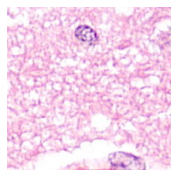

In [30]:
import openslide, numpy as np, matplotlib.pyplot as plt
from PIL import Image

mrxs_path = "/Volumes/Expansion/wsi-annotated/DigitalSlide_A1M_1S_1_20230920092719241.mrxs"
slide = openslide.OpenSlide(mrxs_path)

bx = int(slide.properties.get("openslide.bounds-x", 0))
by = int(slide.properties.get("openslide.bounds-y", 0))
print("bounds offset:", bx, by)

PATCH = 224
cx, cy = 13664, 19282  # your polygon center example

def read_qpath_xy(x, y, size=224, level=1):
    x0 = int(x + bx - size//2)
    y0 = int(y + by - size//2)
    img = slide.read_region((x0, y0), level, (size, size))  # RGBA
    arr = np.asarray(img, dtype=np.uint8)
    return arr

arr = read_qpath_xy(cx, cy, PATCH, 0)
print("RGB mean:", arr[..., :3].mean(), "alpha mean:", arr[..., 3].mean())

plt.figure(figsize=(3,3))
plt.imshow(arr[..., :3])
plt.axis("off")
plt.show()

In [42]:
import os
import glob

BASE_DIRS = [
    "/Users/sandeepsharma/Downloads/Tumor patch extraction/src/results/patches_raw/0",
    "/Users/sandeepsharma/Downloads/Tumor patch extraction/src/results/patches_raw/1",
    "/Users/sandeepsharma/Downloads/Tumor patch extraction/src/results/patches_norm/0",
    "/Users/sandeepsharma/Downloads/Tumor patch extraction/src/results/patches_norm/1",
]

BAD_SLIDE_ID = "DigitalSlide_A1M_1S_1_20230920092719241"

n_deleted = 0

for d in BASE_DIRS:
    if not os.path.isdir(d):
        continue

    pattern = os.path.join(d, f"*{BAD_SLIDE_ID}*.png")
    files = glob.glob(pattern)

    for f in files:
        os.remove(f)
        n_deleted += 1

print(f"Deleted {n_deleted} patches for slide {BAD_SLIDE_ID}")

Deleted 0 patches for slide DigitalSlide_A1M_1S_1_20230920092719241


In [48]:
import pandas as pd

train = pd.read_csv("/Users/sandeepsharma/Downloads/Tumor patch extraction/src/results/splits/train.csv")
val   = pd.read_csv("/Users/sandeepsharma/Downloads/Tumor patch extraction/src/results/splits/val.csv")

train_slides = set(train["slide_id"].unique())
val_slides   = set(val["slide_id"].unique())

overlap = train_slides & val_slides
print("train slides:", len(train_slides))
print("val slides:", len(val_slides))
print("overlap:", len(overlap))
print("examples:", list(overlap)[:10])

train slides: 54
val slides: 13
overlap: 0
examples: []


In [46]:
import pandas as pd, os, hashlib
from tqdm import tqdm

# train = pd.read_csv("results/splits/train.csv")
# val   = pd.read_csv("results/splits/val.csv")

def md5(path, block=1<<20):
    h = hashlib.md5()
    with open(path, "rb") as f:
        while True:
            b = f.read(block)
            if not b: break
            h.update(b)
    return h.hexdigest()

train_hash = {}
for p in tqdm(train["png_path"].tolist(), desc="hash train"):
    train_hash[p] = md5(p)

val_hash = {}
for p in tqdm(val["png_path"].tolist(), desc="hash val"):
    val_hash[p] = md5(p)

train_set = set(train_hash.values())
val_set   = set(val_hash.values())

dup = train_set & val_set
print("duplicate images across train/val:", len(dup))

hash train:   0%|          | 0/30605 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: 'results/patches_norm/0/006__x102919__y8364__mpp0.253__r443.png'

In [49]:
import pandas as pd

#val = pd.read_csv("results/splits/val.csv")

g = val.groupby("slide_id")["label"].agg(["mean","min","max","size"]).reset_index()
mixed_slides = g[(g["min"]==0) & (g["max"]==1)]["slide_id"].tolist()

val_mixed = val[val["slide_id"].isin(mixed_slides)]
print("val slides total:", val["slide_id"].nunique(), "patches:", len(val))
print("val mixed slides:", len(mixed_slides), "patches:", len(val_mixed))
print(val_mixed["label"].value_counts())

val slides total: 13 patches: 4980
val mixed slides: 5 patches: 2650
label
1    1516
0    1134
Name: count, dtype: int64
